In [1]:
# Modules
import numpy as np
import pandas as pd
import itertools
import destruction_models as models
import tensorflow as tf
import random

from destruction_utilities import *
from destruction_statistics import *
from numpy import random
import matplotlib.pyplot as plt
from tensorflow.keras import callbacks, preprocessing
from tensorflow.keras.utils import Sequence
from tensorflow.keras.metrics import CategoricalAccuracy, Precision, AUC
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_recall_curve, roc_auc_score

from os import path
import zarr
import shutil
import gc
import time
import pickle

# from tensorflow.keras import layers, models, Sequential

In [2]:
CITY = 'aleppo'
TILE_SIZE = (128,128)
BATCH_SIZE = 32

auc = AUC(
    num_thresholds=200,
    curve='ROC',
    name="auc"
)
    

Metal device set to: Apple M1


2022-07-14 20:58:04.879143: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2022-07-14 20:58:04.879238: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
class ZarrGenerator(Sequence):
    def __init__(self, images, labels, batch_size=BATCH_SIZE):
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        
    def __len__(self):
        return len(self.images)//self.batch_size
    
    def __getitem__(self, index):

        X = self.images[index*self.batch_size:(index+1)*self.batch_size]
        y = self.labels[index*self.batch_size:(index+1)*self.batch_size]
        
        return self.augment(X), y.flatten()
    
    def augment(self, X):
#         # Horizontal and vertical flip
#         flipping_funcs = [
#             lambda image: image,
#             lambda image: np.fliplr(image),
#             lambda image: np.flipud(image),
#             lambda image: np.flipud(np.fliplr(image))
#         ]
#         func = random.choice(flipping_funcs)
#         X = func(X)
        
        # Brightness
        alpha = random.choice(np.linspace(0.85, 1.4))
        X = X * alpha
        
        return X

In [4]:
def run_model(training_images, training_labels, validation_images, validation_labels, run_id = 1, epochs=50):
    training_generator = ZarrGenerator(training_images, training_labels, batch_size=BATCH_SIZE)
    validation_generator = ZarrGenerator(validation_images, validation_labels, batch_size=BATCH_SIZE)
    
    training_callbacks = [
        callbacks.EarlyStopping(monitor='val_auc', restore_best_weights=True, patience=3),
        callbacks.ModelCheckpoint(f'../models/{CITY}/cnn/run_{run_id}', monitor='val_auc', verbose=0, save_best_only=True, save_weights_only=False, mode='max')
    ]
    
    filters = random.choice([16, 24, 32])
    dropout = random.choice(np.linspace(0.05, 0.5))
    epochs = random.choice([10,15])
    units = random.choice([24, 32, 48])
    lr = random.choice([0.003, 0.01, 0.03])
    
    parameters = f'Model parameters: \nfilters={filters}, \ndropout={dropout}, \nepochs={epochs}, \nunits={units}, \nlearning_rate={lr}'
    print(parameters)
    
    args  = dict(shape=(*TILE_SIZE, 3), filters=filters, units=units, dropout=dropout) # ! Check parameters before run
    model = models.convolutional_network(**args)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', f1_m, precision_m, recall_m, auc])

    model.summary()
    
    # Train model on dataset
    history = model.fit_generator(
        training_generator,
        validation_data=validation_generator, 
        epochs=epochs, 
        callbacks = training_callbacks
    )
    
    return model, history, parameters


# def calculate_auc(model, test_images, test_labels):
#     gc.collect(generation=2)    
#     batch_size = 5000
#     iters = test_images.shape[0] // batch_size
#     preds = []
#     labels = []
#     for i in range(0, iters):
#         end = (i+1)*batch_size
#         if i == iters - 1:
#             preds.append(model.predict(test_images[i*batch_size:]))
#             labels.append(test_labels[i*batch_size:])
#         else:
#             preds.append(model.predict(test_images[i*batch_size: end]))
#             labels.append(test_labels[i*batch_size: end])
            
#     yhat = np.squeeze(np.concatenate(preds, axis=0))
#     y = np.squeeze(np.concatenate(labels, axis=0 ))
#     roc_auc = roc_auc_score(y, yhat)
    
#     return roc_auc
    

In [5]:
training_images = read_zarr(CITY, 'images_conv_train_balanced')
training_labels = read_zarr(CITY, 'labels_conv_train_balanced')
validation_images = read_zarr(CITY, 'images_conv_valid')
validation_labels = read_zarr(CITY, 'labels_conv_valid')
test_images = read_zarr(CITY, 'images_conv_test')
test_labels = read_zarr(CITY, 'labels_conv_test')

In [6]:
training_images.shape

(203688, 128, 128, 3)

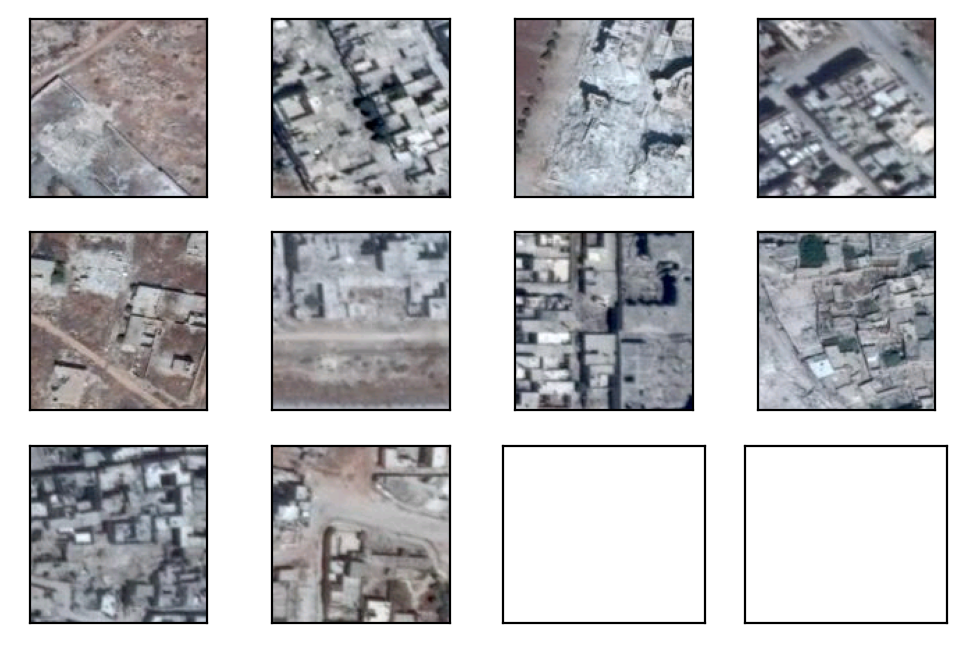

In [7]:
import matplotlib.pyplot as plt
labels = np.squeeze([training_labels[0:30]])
ones = np.where(labels==1)
images = training_images[0:100]

total_images = len(list(ones[0]))
fig, ax = plt.subplots(3, (total_images//3)+1, dpi=200, figsize =(6,4))
ax = ax.flatten()


for i, one in enumerate(list(ones[0])):
    ax[i].imshow(images[one].astype(np.uint8))

for a in ax:
    a.set_xticks([])
    a.set_yticks([])



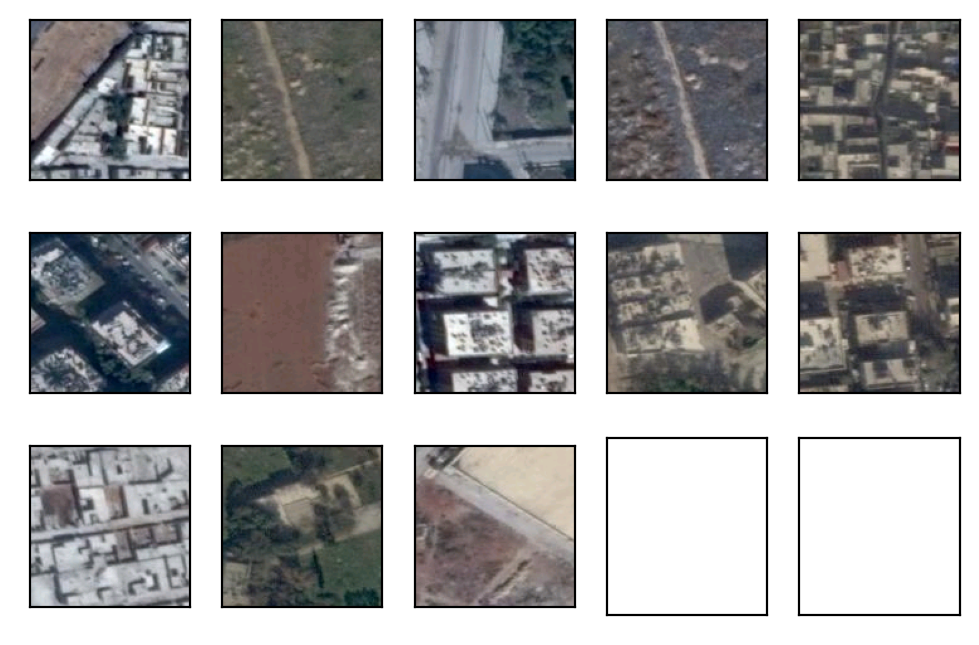

In [8]:
import matplotlib.pyplot as plt
labels = np.squeeze([training_labels[0:17]])
zeros = np.where(labels==0)
images = training_images[0:20]

total_images = len(list(zeros[0]))
fig, ax = plt.subplots(3, (total_images//3)+1, dpi=200, figsize =(6,4))
ax = ax.flatten()


for i, one in enumerate(list(zeros[0])):
    ax[i].imshow(images[one].astype(np.uint8))

for a in ax:
    a.set_xticks([])
    a.set_yticks([])



In [9]:
def plot_training(H, P, ts, plotPath):
	# construct a plot that plots and saves the training history
	plt.style.use("ggplot")
	plt.figure()
	plt.plot(H.history["accuracy"], label="train_accuracy")
	plt.plot(H.history["val_accuracy"], label="val_accuracy")
	plt.plot(H.history["auc"], label="train_auc")
	plt.plot(H.history["val_auc"], label="val_auc")
	plt.title(f"Training Accuracy and AUC")
	plt.suptitle(f"City = {CITY}") 
	plt.xlabel("Epoch #")
	plt.ylabel("AUC")
	plt.text(0.65, 0.18, P + f"\nmax(val_auc)={np.round(np.max(H.history['val_auc']), 4)}\ncode={ts}", fontsize=8, transform=plt.gcf().transFigure)
	plt.legend(loc="lower left")
	plt.savefig(plotPath)

Model parameters: 
filters=24, 
dropout=0.30714285714285716, 
epochs=10, 
units=24, 
learning_rate=0.003
Model: "convolutional_network"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inputs (InputLayer)         [(None, 128, 128, 3)]     0         
                                                                 
 conv_block1_convolution (Co  (None, 128, 128, 24)     648       
 nv2D)                                                           
                                                                 
 conv_block1_pooling (MaxPoo  (None, 64, 64, 24)       0         
 ling2D)                                                         
                                                                 
 conv_block1_normalisation (  (None, 64, 64, 24)       96        
 BatchNormalization)                                             
                                                                 
 conv_

/var/folders/z1/7pydgng971nfzdf2rwg_p__r0000gn/T/ipykernel_89267/2046137429.py:27: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(
2022-07-14 20:58:06.054549: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2022-07-14 20:58:07.079031: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


6365/6365 [==============================] - ETA: 0s - loss: 0.5433 - accuracy: 0.7298 - f1_m: 0.7273 - precision_m: 0.7139 - recall_m: 0.7947 - auc: 0.7995

2022-07-14 21:12:26.306631: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-14 21:15:48.956421: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


INFO:tensorflow:Assets written to: ../models/aleppo/cnn/run_0/assets
6365/6365 [==============================] - 1065s 167ms/step - loss: 0.5433 - accuracy: 0.7298 - f1_m: 0.7273 - precision_m: 0.7139 - recall_m: 0.7947 - auc: 0.7995 - val_loss: 0.2830 - val_accuracy: 0.9148 - val_f1_m: 0.0793 - val_precision_m: 0.0687 - val_recall_m: 0.1318 - val_auc: 0.7695
Epoch 2/10
6365/6365 [==============================] - 1082s 170ms/step - loss: 0.4783 - accuracy: 0.7752 - f1_m: 0.7723 - precision_m: 0.7498 - recall_m: 0.8473 - auc: 0.8479 - val_loss: 0.4600 - val_accuracy: 0.7722 - val_f1_m: 0.1467 - val_precision_m: 0.0996 - val_recall_m: 0.4180 - val_auc: 0.8126
Epoch 3/10
6365/6365 [==============================] - 1137s 179ms/step - loss: 0.3984 - accuracy: 0.8268 - f1_m: 0.8207 - precision_m: 0.7912 - recall_m: 0.8962 - auc: 0.8945 - val_loss: 0.5659 - val_accuracy: 0.7107 - val_f1_m: 0.1499 - val_precision_m: 0.0948 - val_recall_m: 0.4928 - val_auc: 0.8144
Epoch 4/10
6365/6365 [=====

...

Trainable params: 157,057
Non-trainable params: 672
_________________________________________________________________
Epoch 1/15


/var/folders/z1/7pydgng971nfzdf2rwg_p__r0000gn/T/ipykernel_89267/2046137429.py:27: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(
2022-07-15 03:43:07.722349: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


6365/6365 [==============================] - ETA: 0s - loss: 0.5454 - accuracy: 0.7278 - f1_m: 0.7253 - precision_m: 0.7123 - recall_m: 0.7942 - auc: 0.8057

2022-07-15 03:52:03.508855: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


INFO:tensorflow:Assets written to: ../models/aleppo/cnn/run_4/assets
6365/6365 [==============================] - 745s 117ms/step - loss: 0.5454 - accuracy: 0.7278 - f1_m: 0.7253 - precision_m: 0.7123 - recall_m: 0.7942 - auc: 0.8057 - val_loss: 0.2573 - val_accuracy: 0.9019 - val_f1_m: 0.1390 - val_precision_m: 0.1205 - val_recall_m: 0.2188 - val_auc: 0.8151
Epoch 2/15
6365/6365 [==============================] - 710s 111ms/step - loss: 0.4655 - accuracy: 0.7844 - f1_m: 0.7808 - precision_m: 0.7567 - recall_m: 0.8580 - auc: 0.8547 - val_loss: 0.3111 - val_accuracy: 0.8475 - val_f1_m: 0.1482 - val_precision_m: 0.1113 - val_recall_m: 0.3216 - val_auc: 0.8056
Epoch 3/15
6365/6365 [==============================] - 718s 113ms/step - loss: 0.3689 - accuracy: 0.8447 - f1_m: 0.8371 - precision_m: 0.8079 - recall_m: 0.9095 - auc: 0.9102 - val_loss: 0.3135 - val_accuracy: 0.8533 - val_f1_m: 0.1485 - val_precision_m: 0.1126 - val_recall_m: 0.3039 - val_auc: 0.7875
Epoch 4/15
6365/6365 [========

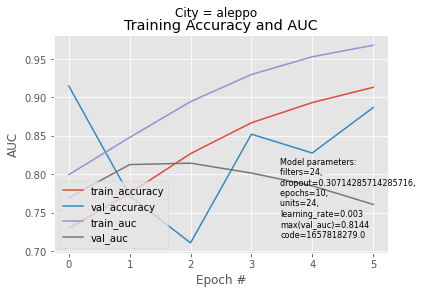

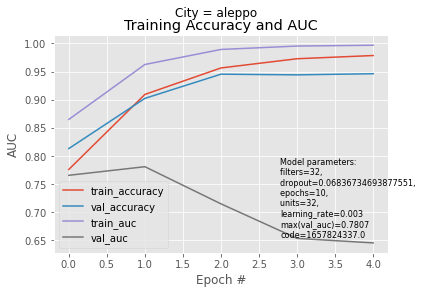

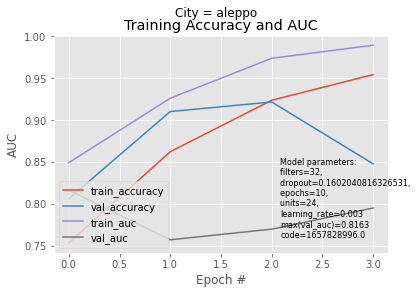

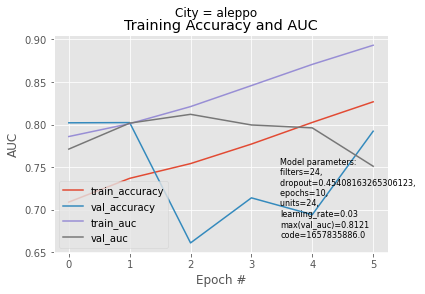

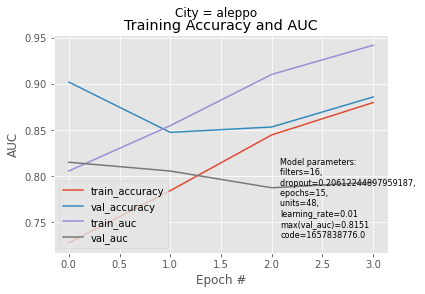

In [10]:
for i in range(0,5):
    m = run_model(training_images, training_labels, validation_images, validation_labels, run_id = i)
    model = m[0]
    history = m[1]
    parameters = m[2]
    print("Model optimization complete..\n\n")
    ts = str(np.round(time.time()))
    with open(f'../models/{CITY}_CNN_RUN{i}_{ts}_hist', 'wb') as file_pi:
        pickle.dump(history.history, file_pi)
    
    model.save(f'../models/{CITY}_CNN_RUN{i}_{ts}', save_format="h5")
    plot_training(history, parameters, ts, f'../figures/{CITY}_CNN_RUN{i}_{ts}.png')
    
    with open('../models/run_parameters.txt', "a") as file:
        file.write(f'{CITY}_CNN_RUN{i}_{ts}: \n \t{parameters}\n')
      


2022-07-15 04:31:20.376654: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 0
Test Set AUC Score for the ROC Curve: 0.803361672819139


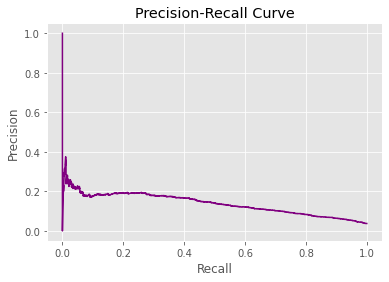

2022-07-15 04:34:40.301287: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 1
Test Set AUC Score for the ROC Curve: 0.7854660633976893


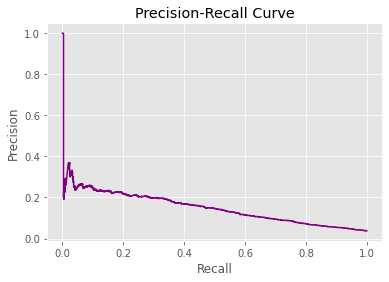

2022-07-15 04:38:01.556636: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 2
Test Set AUC Score for the ROC Curve: 0.807996744089815


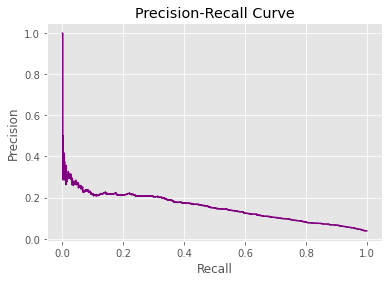

2022-07-15 04:41:20.271738: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 3
Test Set AUC Score for the ROC Curve: 0.8087411660296409


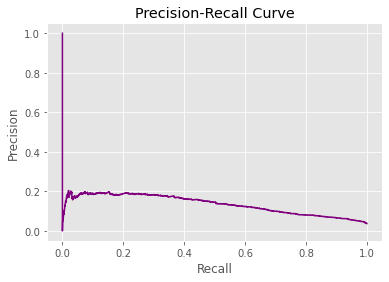

2022-07-15 04:44:39.028363: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 4
Test Set AUC Score for the ROC Curve: 0.8028064257946491


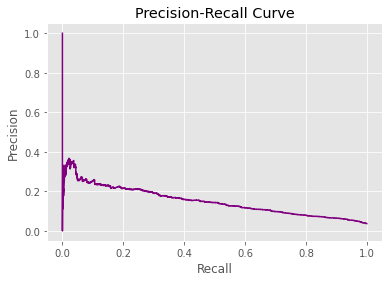

In [11]:
class CNNTestGenerator(Sequence):
    def __init__(self, images, batch_size=32):
        self.images = images
        self.batch_size = batch_size
        
    def __len__(self):
        return len(self.images)//self.batch_size
    
    def __getitem__(self, index):
        if(index == self.__len__()-1):
            X = self.images[index*self.batch_size:len(self.images)]
        else:
            X = self.images[index*self.batch_size:(index+1)*self.batch_size]            
        return X
    
    def augment(self, X):        
        # Brightness
        alpha = random.choice(np.linspace(0.85, 1.4))
        X = X * alpha
        
        return X

for i in range(0,5):
    model_path = f'../models/{CITY}/cnn/run_{i}'
    best_model = load_model(model_path, custom_objects={'f1_m':f1_m, 'precision_m': precision_m, 'recall_m': recall_m, 'auc': auc})
    test_generator = CNNTestGenerator(test_images)

    yhat_proba, y = np.squeeze(best_model.predict(test_generator)), np.squeeze(test_labels[:])

    roc_auc_test = roc_auc_score(y, yhat_proba)

    #calculate precision and recall
    precision, recall, thresholds = precision_recall_curve(y, yhat_proba)

    #create precision recall curve
    fig, ax = plt.subplots()
    ax.plot(recall, precision, color='purple')

    #add axis labels to plot
    ax.set_title('Precision-Recall Curve')
    ax.set_ylabel('Precision')
    ax.set_xlabel('Recall')

    print(f'Run {i}\nTest Set AUC Score for the ROC Curve: {roc_auc_test}' )

    #display plot
    plt.show()